<a href="https://colab.research.google.com/github/sauravpatil045/MLOPS1.THIRD-YEAR/blob/main/mlops1_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1155]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [1156]:
data = {
    "Study_Hours": [1,2,3,4,5,6,7,8,9,10],
    "Attendance": [60,85,70,95,65,80,90,75,88,72],
    "Marks": [32,42,47,58,63,67,76,79,88,91],
}
# Convert dict into Dataframe
df = pd.DataFrame(data)
print(df)


   Study_Hours  Attendance  Marks
0            1          60     32
1            2          85     42
2            3          70     47
3            4          95     58
4            5          65     63
5            6          80     67
6            7          90     76
7            8          75     79
8            9          88     88
9           10          72     91


In [1157]:
print('First Five Rows:')
df.head()

First Five Rows:


,Study_Hours,Attendance,Marks
0,1,60,32
1,2,85,42
2,3,70,47
3,4,95,58
4,5,65,63


In [1158]:
print('Shape of Dataset:')
df.shape

Shape of Dataset:


(10, 3)

In [1159]:
print('Information:')
df.info()

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Study_Hours  10 non-null     int64
 1   Attendance   10 non-null     int64
 2   Marks        10 non-null     int64
dtypes: int64(3)
memory usage: 372.0 bytes


In [1160]:
print('Stastical Analysis:\n', df.describe())

Stastical Analysis:
        Study_Hours  Attendance      Marks
count     10.00000   10.000000  10.000000
mean       5.50000   78.000000  64.300000
std        3.02765   11.489125  19.765571
min        1.00000   60.000000  32.000000
25%        3.25000   70.500000  49.750000
50%        5.50000   77.500000  65.000000
75%        7.75000   87.250000  78.250000
max       10.00000   95.000000  91.000000


In [1161]:
print('Check for null values:')
df.isnull().sum()

Check for null values:


,0
Study_Hours,0
Attendance,0
Marks,0


In [1162]:
# Duplicate Values
df.duplicated().sum()

np.int64(0)

In [1163]:
df.drop_duplicates()

,Study_Hours,Attendance,Marks
0,1,60,32
1,2,85,42
2,3,70,47
3,4,95,58
4,5,65,63
5,6,80,67
6,7,90,76
7,8,75,79
8,9,88,88
9,10,72,91


Text(0.5, 1.0, 'Correction Heatmap')

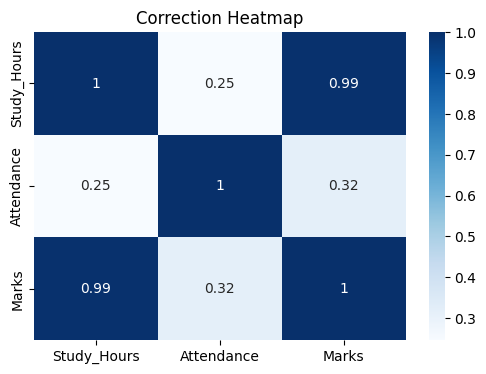

In [1164]:
# Correction Heatmap
import seaborn as sns

df_corr = df.corr()

plt.figure(figsize= ( 6, 4))
sns.heatmap(df_corr, annot=True, cmap='Blues')

plt.title('Correction Heatmap')

In [1165]:
# Feature Selection
x=df[['Study_Hours']] # Independent Variable
y=df['Marks'] # Dependent Variable

In [1166]:
x

,Study_Hours
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


In [1167]:
# Split dataset into training and testing set
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [1168]:
x_test

,Study_Hours
8,9
1,2


In [1169]:
# Import Model
from sklearn.linear_model import LinearRegression
model = LinearRegression()

# Train the model
model.fit(x_train, y_train)

LinearRegression()

In [1170]:
# Predict the values
y_pred = model.predict(x_test)
y_pred

array([86.72413793, 41.52586207])

In [1171]:
# Print Equation
print('Intercept:', model.intercept_)
print('Slope:', model.coef_[0])

Intercept: 28.61206896551724
Slope: 6.456896551724138


In [1172]:
# SLR EQUATION
Marks_predicted_from_equation = (6.48 * df['Study_Hours']) + 28.27

In [1173]:
# Evaluation
from sklearn.metrics import root_mean_squared_error, r2_score, mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('RMSE:',round(rmse,3))
print('R2 Score:', round(r2, 2))

RMSE: 0.962
R2 Score: 1.0


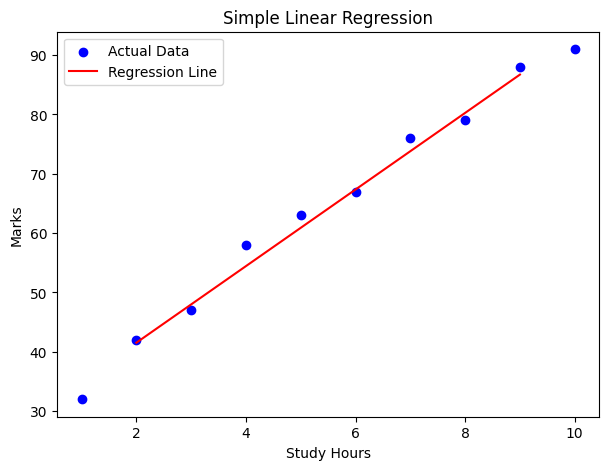

In [1174]:
# Regression line
plt.figure(figsize=(7, 5))
plt.scatter(x, y, color='blue', label='Actual Data')
plt.plot(x_test, y_pred, color='red', label='Regression Line')
plt.xlabel('Study Hours')
plt.ylabel('Marks')
plt.title('Simple Linear Regression')
plt.legend()
plt.show()

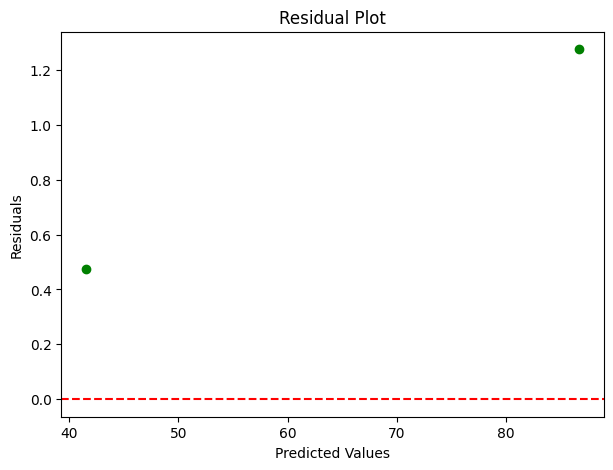

In [1175]:
residuals = y_test - y_pred #Calculate Residual

plt.figure(figsize=(7, 5))
plt.scatter(y_pred, residuals, color='green')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

In [1176]:
x =df["Study_Hours"].values #Independent Variable (features)
y =df["Marks"].values #Dependent Variables (Target)

In [1177]:
x

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

In [1178]:
# Calculate Mean
x_mean = np.mean(x)
y_mean = np.mean(y)

In [1179]:
x_mean

np.float64(5.5)

In [1180]:
# Calculate Slope
m = np.sum((x-x_mean)*(y-y_mean))/np.sum((x-x_mean)**2)
# Calculate intercept
b =y_mean - (m*x_mean)

print("Slope =", m)
print("Intersept =", b)

Slope = 6.490909090909091
Intersept = 28.599999999999994


In [1181]:
# Prediction
y_pred_numpy =m*x + b
y_pred_numpy

array([35.09090909, 41.58181818, 48.07272727, 54.56363636, 61.05454545,
       67.54545455, 74.03636364, 80.52727273, 87.01818182, 93.50909091])

In [1182]:
# Feature Selection
x=df[['Study_Hours', 'Attendance']] # Independent Variable
y=df['Marks'] # Dependent Variable
# Spilit Database
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [1183]:
x_train

,Study_Hours,Attendance
0,1,60
7,8,75
2,3,70
9,10,72
4,5,65
3,4,95
6,7,90


In [1184]:
model=LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [1185]:
# Prediction
y_pred =model.predict(x_test)
y_pred

array([88.13111898, 43.64291936, 68.03285708])

In [1186]:
# Model Parameters
print('Intercept:', model.intercept_)
print("Coefficients",)
coeff=pd.DataFrame({
    'Feature': x.columns, 'Coefficient': model.coef_ })

print(coeff)

Intercept: 18.000439614116488
Coefficients
       Feature  Coefficient
0  Study_Hours     6.289592
1   Attendance     0.153686


In [1187]:
# Evaluation Metrics
from sklearn.metrics import mean_absolute_error

print('Metrics Values Of MLR:')
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print('MAE:', mae)
print('RMSE:', round(rmse, 2))
print('R2 Score:', round(r2, 2))

Metrics Values Of MLR:
MAE: 0.9356318096090964
RMSE: 1.12
R2 Score: 1.0


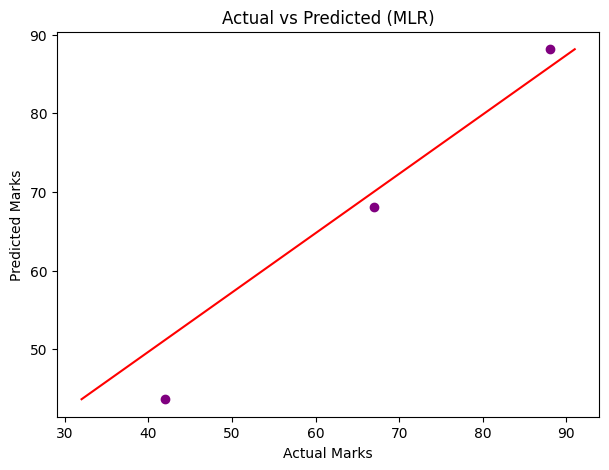

In [1188]:
# Actual vs Predicted Plot
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, color='purple')

# Perfect Prediction Line
plt.plot([y.min(), y.max()],
         [y_pred.min(), y_pred.max()], color='red')

plt.xlabel('Actual Marks')
plt.ylabel('Predicted Marks')
plt.title('Actual vs Predicted (MLR)')
plt.show()

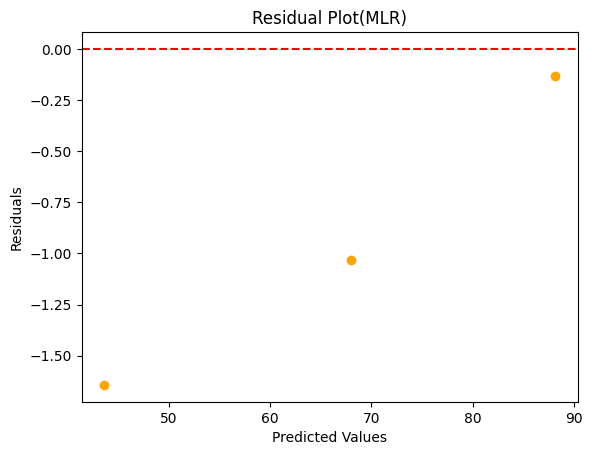

In [1189]:
residuals = y_test - y_pred #Calculate Residual

plt.scatter(y_pred, residuals, color='Orange')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot(MLR)')
plt.show()